# Exploratory Data Analysis (EDA)

## 1. Dataset Overview

### 1.1 Total Number of Users

We first retrieve the total number of unique users in the dataset.

- Total users

This gives us the scale of user participation in the system.

---

### 1.2 Total Number of Movies

Next, we retrieve the total number of unique movies available.

- Total movies:

This tells us the size of the item space for recommendations.

---

## 2. Movie Ratings Analysis

### 2.1 Most Rated Movies (By Number of Ratings)

To determine this, we rank movies by the total number of ratings received.
Top movies by rating count:

---



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import mysql.connector
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.2f}'.format)



In [2]:
df_links = pd.read_csv('../datasets/cleaned_datasets/links_cleaned.csv')
df_movies = pd.read_csv('../datasets/cleaned_datasets/movies_cleaned.csv')
df_ratings = pd.read_csv('../datasets/cleaned_datasets/ratings_cleaned.csv')
df_tags = pd.read_csv('../datasets/cleaned_datasets/tags_cleaned.csv')

In [3]:
cnx = mysql.connector.connect( # Connecting to the database
    host = "127.0.0.1",
    user = 'root',
    password = '',
    port = 3306,
    database = 'movierecodb'
)

cur = cnx.cursor()

---

- #### Total Numbers of Users: 

In [4]:

cur.execute("Select count(*) from users")
user_count = cur.fetchone()[0]
print(f'Total Number of Users: {user_count}')

Total Number of Users: 59937


- #### Most Rated Movies

In [5]:
mv_series = df_ratings.groupby('movieId')['rating'].count().reset_index().iloc[:10]['movieId']
movie_names = df_movies.loc[df_movies['movieId'].isin(mv_series),'title']
print(f'Movie Titles: {list(movie_names)}')

Movie Titles: ['Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)', 'Waiting to Exhale (1995)', 'Father of the Bride Part II (1995)', 'Heat (1995)', 'Sabrina (1995)', 'Tom and Huck (1995)', 'Sudden Death (1995)', 'GoldenEye (1995)']


A bias can be located. It seems that 1995 movies have accumulated the most ratings counts. That rules back to the fact that those movies have been around for long enough to accumulate more ratings.

# 3. Genre Analysis

## 3.1 Unique Genres

In this section, we examine the different genres available in the dataset.

* List of all genres

This helps us understand the diversity of content in the movie catalog of the dataset.

---

## 3.2 Number of Movies per Genre

We analyze how many movies belong to each genre.

This reveals:

* Which genres dominate the dataset
* Whether the dataset is balanced or skewed toward certain genres
* Which genres are underrepresented

Understanding this distribution is important when interpreting later rating trends.

---

## 3.3 Number of Ratings per Genre

Here, we examine how many total ratings each genre has received.

This helps identify:

* The most engaged-with genres
* Which genres drive the majority of user interaction
* Differences between content availability and actual user interest

A genre with many movies does not necessarily have the most user engagement.

---

## 3.4 Average Rating per Genre

We compute the mean rating for each genre to determine which genres are generally rated higher by users.

This analysis helps answer:

* Which genres are most appreciated
* Whether highly rated genres are also the most popular
* Differences between popularity and perceived quality

It is important to note that average ratings alone can be misleading if based on a small number of ratings.

---


- #### List Of Genres

In [6]:
cur.execute("Select genre from genres")
cur.fetchall()

[('Comedy',),
 ('Children',),
 ('Crime',),
 ('Sci-Fi',),
 ('Drama',),
 ('Fantasy',),
 ('Thriller',),
 ('Romance',),
 ('Documentary',),
 ('War',),
 ('(no genres listed)',),
 ('Animation',),
 ('Musical',),
 ('Action',),
 ('Film-Noir',),
 ('Western',),
 ('Adventure',),
 ('Mystery',),
 ('IMAX',),
 ('Horror',)]

- Number of Movies per Genre

In [7]:
df_movies['genres'] = df_movies['genres'].str.split('|')
df_numMovies = df_movies.explode('genres').groupby('genres')['movieId'].count().reset_index().rename(columns = {'movieId' : 'movieCount'}).copy()
df_numMovies 

,genres,movieCount
0,(no genres listed),301
1,Action,3633
2,Adventure,2328
3,Animation,1554
4,Children,1439
5,Comedy,7878
6,Crime,2605
7,Documentary,1676
8,Drama,11187
9,Fantasy,1572


<Axes: xlabel='genres', ylabel='movieCount'>

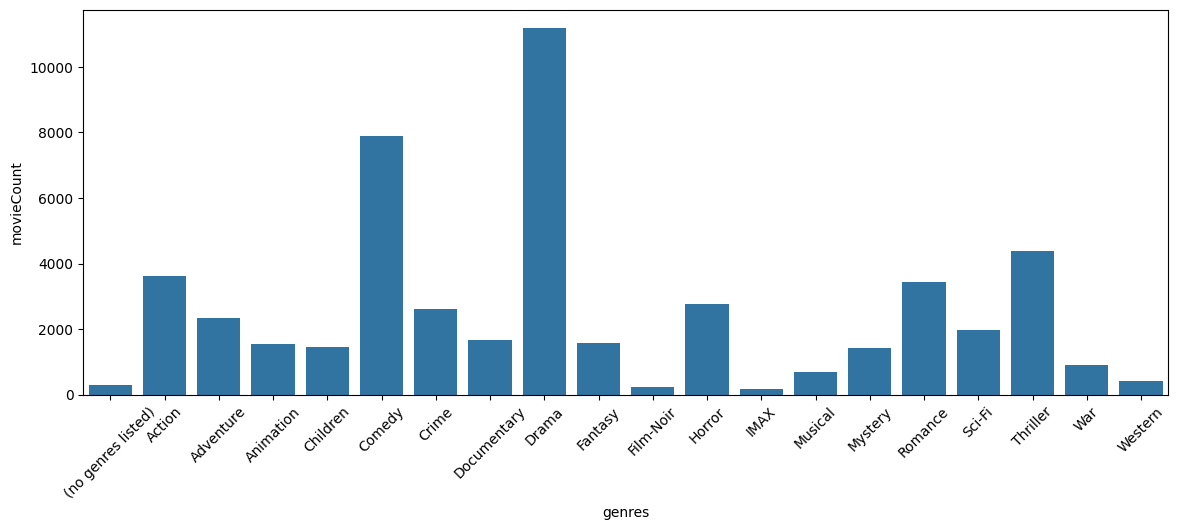

In [8]:
plt.figure(figsize = (14,5))
plt.xticks(rotation=45)
sns.barplot(data = df_numMovies, x = 'genres', y = 'movieCount')


- Number of Ratings per Genre

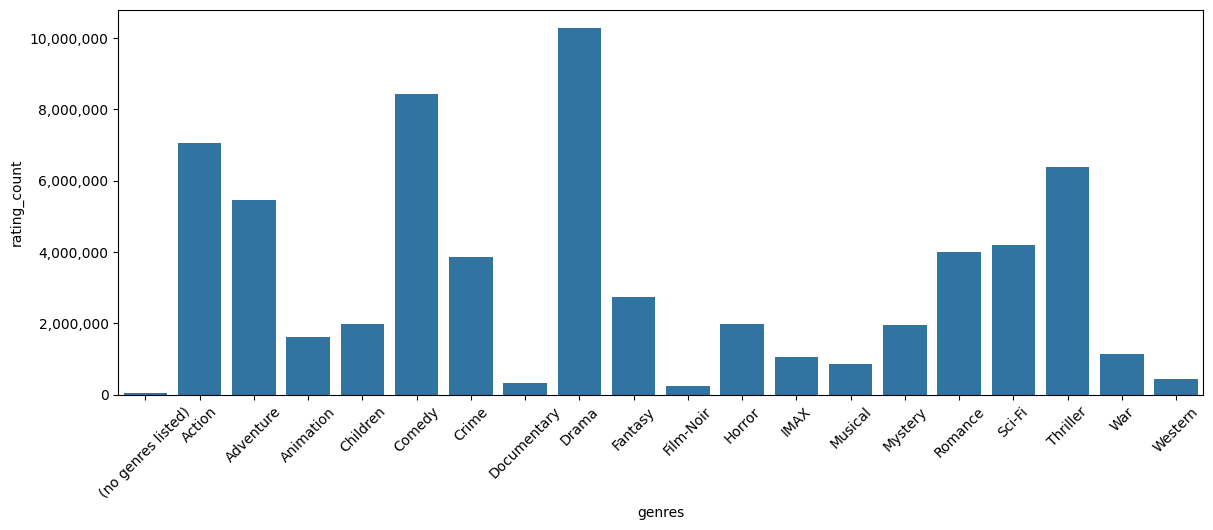

In [9]:
import matplotlib.ticker as mtick
df_concat = pd.concat([df_movies, df_ratings.groupby('movieId')['rating'].count().reset_index().rename(columns={'rating' : 'rating_count'})['rating_count']],axis=1)
df_concat = df_concat.explode('genres')
plt.figure(figsize = (14,5))
plt.xticks(rotation=45) 
ax = sns.barplot(
    data=df_concat.groupby('genres')['rating_count'].sum().reset_index(),
    x='genres', y='rating_count'
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

We can conclude that drama has the most user-rating interactions

- #### Average Rating per Genre

In [10]:
df_ratings.merge(df_movies, on = 'movieId', how = 'inner').explode('genres').groupby('genres')['rating'].mean().reset_index()

,genres,rating
0,(no genres listed),3.49
1,Action,3.39
2,Adventure,3.44
3,Animation,3.55
4,Children,3.37
5,Comedy,3.37
6,Crime,3.61
7,Documentary,3.69
8,Drama,3.62
9,Fantasy,3.43


---

### Correlation Analysis: Movie Popularity vs. Average Rating

We explore whether more popular movies (higher number of ratings) tend to receive better average ratings.

For each movie, we compute:
- rating_count — total number of ratings received
- avg_rating — mean rating across all users

We then correlate these two metrics to check if popularity and quality go hand in hand.

In [11]:
df_ratings.groupby('movieId')['rating'].agg(['mean','count']).corr()

,mean,count
mean,1.00,0.20
count,0.20,1.00
